In [4]:
df = pd.read_csv('C:\\MACHINE LEARNING\\TIME SERIES\\DATASETS\\retail_store_inventory.csv')

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [6]:
df = pd.get_dummies(df, columns = ['Category', 'Region', 'Seasonality', 'Weather Condition', 'Store ID', 'Product ID'])

In [7]:
q1 = df['Demand Forecast'].quantile(0.25)
q3 = df['Demand Forecast'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 *iqr
lower = q1 - 1.5 *iqr

df = df[(df['Demand Forecast'] <= upper) & (df['Demand Forecast'] >= lower)]

In [10]:
df = df.rename(columns = {'Date' : 'ds', 'Demand Forecast' : 'y'})

In [11]:
dp = df[['ds', 'y']].copy()

In [17]:
train_xg = df[(df['ds'] >= pd.Timestamp('2022-01-01')) & (df['ds'] <= pd.Timestamp('2023-06-01'))]
test_xg = df[(df['ds'] >= pd.Timestamp('2023-06-02')) & (df['ds'] <= pd.Timestamp('2024-01-01'))]

train = dp[(dp['ds'] >= pd.Timestamp('2022-01-01')) & (dp['ds'] <= pd.Timestamp('2023-06-01'))]
test = dp[(dp['ds'] >= pd.Timestamp('2023-06-02')) & (dp['ds'] <= pd.Timestamp('2024-01-01'))]

In [18]:
model = Prophet(changepoint_prior_scale= 0.001, seasonality_prior_scale= 1, daily_seasonality= True, weekly_seasonality= True,
                yearly_seasonality= True, holidays_prior_scale= 5)
model.fit(train)


17:48:57 - cmdstanpy - INFO - Chain [1] start processing
17:48:59 - cmdstanpy - INFO - Chain [1] done processing


In [19]:
predict_train = model.predict(train)
predict_test = model.predict(test)

predict_train = predict_train['yhat'].values
predict_test = predict_test['yhat'].values

y_train_prop = train['y'].values
y_test_prop = test['y'].values

In [20]:
mae_train = mean_absolute_error(y_train_prop, predict_train)
print ("TRAIN ERROR:%.2f"%mae_train)
mae_test = mean_absolute_error(y_test_prop, predict_test)
print ("TEST ERROR:%.2f"%mae_test)

TRAIN ERROR:86.29
TEST ERROR:86.07


In [21]:
train_xg['Predictions'] = predict_train
train_xg['Residuals'] = train_xg['y'] - train_xg['Predictions']

test_xg['Predictions'] = predict_test
test_xg['Residuals'] = test_xg['y'] - test_xg['Predictions']

In [22]:
train_xg = train_xg.set_index('ds')
test_xg = test_xg.set_index('ds')

In [23]:
def time(df):
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    df['Day'] = df.index.day 
    df['Dayofweek'] = df.index.dayofweek
    df['Dayofyear'] = df.index.dayofyear
    return df

def features(df):
    df['Lag 1'] = df['Residuals'].shift(1)
    df['Lag 7'] = df['Residuals'].shift(7)
    df['Lag 30'] = df['Residuals'].shift(-30)
    df['MA 7'] = df['Residuals'].shift(1).rolling(7).mean()
    df['MA 30'] = df['Residuals'].shift(1).rolling(30).mean()
    df['STD 7'] = df['Residuals'].shift(1).rolling(7).std()
    df['STD 30'] = df['Residuals'].shift(1).rolling(30).std()
    return df

In [24]:
train_xg = time(train_xg)
train_xg = features(train_xg)
test_xg = time(test_xg)
test_xg = features(test_xg)

In [25]:
x_train_xg = train_xg.drop(['Residuals', 'y'], axis = 1)
y_train_xg = train_xg['Residuals']

x_test_xg = test_xg.drop(['Residuals', 'y'], axis = 1)
y_test_xg = test_xg['Residuals']

In [26]:
xg = XGBRegressor(n_estimators = 1500, learning_rate = 0.005, max_depth = 5)
xg.fit(x_train_xg, y_train_xg)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [27]:
pred_train = xg.predict(x_train_xg)
pred_test = xg.predict(x_test_xg)


In [28]:
pred_final_train = train_xg['Predictions'].values + pred_train
pred_final_test = test_xg['Predictions'].values + pred_test

In [29]:
y_train_final = train_xg['y'].values
y_test_final = test_xg['y'].values

In [30]:
mae_final_train = mean_absolute_error(y_train_final,
                                      pred_final_train)
print ("TRAIN FINAL ERROR:%.2f"%mae_final_train)

mae_final_test = mean_absolute_error(y_test_final,
                                     pred_final_test)
print ("TEST FINAL ERROR:%.2f"%mae_final_test)

TRAIN FINAL ERROR:7.31
TEST FINAL ERROR:7.59


In [38]:
residuals = y_test_final - pred_final_test

In [31]:
df['y'].mean()

np.float64(138.2516920462083)

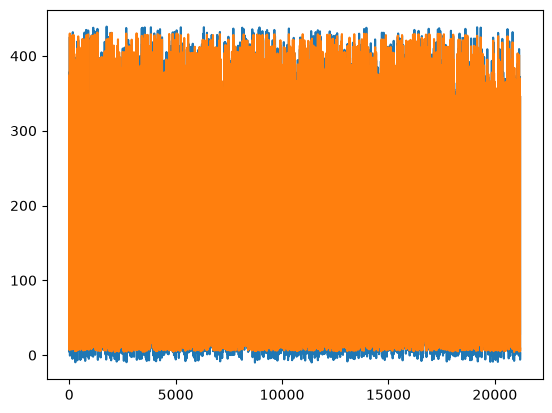

In [37]:
import matplotlib.pyplot as plt

plt.plot(y_test_final)
plt.plot(pred_final_test)

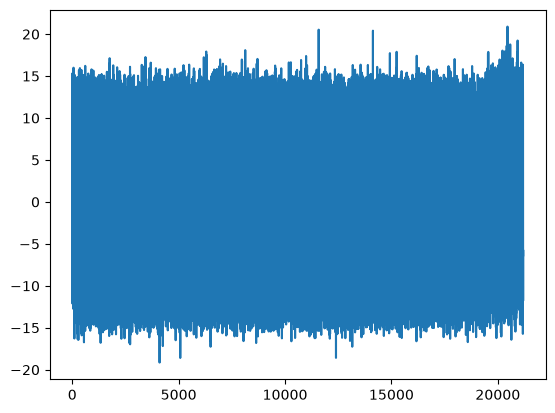

In [40]:
plt.plot(residuals)

In [41]:
residuals.mean()

np.float64(0.16465409747202292)

In [46]:
df['Persistence'] = df['y'].shift(1)
mae_per = mean_absolute_error(df['y'].iloc[1:], df['Persistence'].iloc[1:])
print ("Persistence Error:%.2f"%mae_per)

Persistence Error:116.32
